<a href="https://colab.research.google.com/github/rajib-ui/Quantization-and-PCM_1/blob/main/Quantization_and_PCM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


2-BIT QUANTIZATION
Number of levels: 4
Step size: 0.5
Index validation: True
PCM word length validation: True
First 10 quantization indices:
[2 2 2 2 2 2 2 2 2 2]
First 10 PCM words:
['10', '10', '10', '10', '10', '10', '10', '10', '10', '10']
MSE: 0.02620555581818377
Measured SQNR: 12.80576628841188 dB
Theoretical SQNR: 13.799999999999999 dB


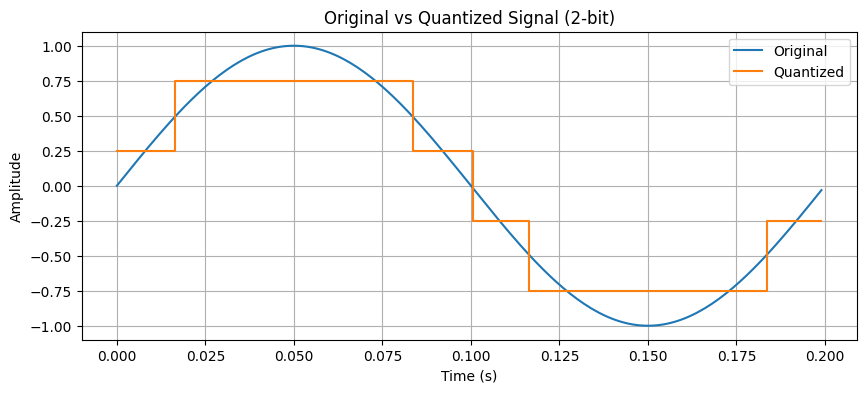

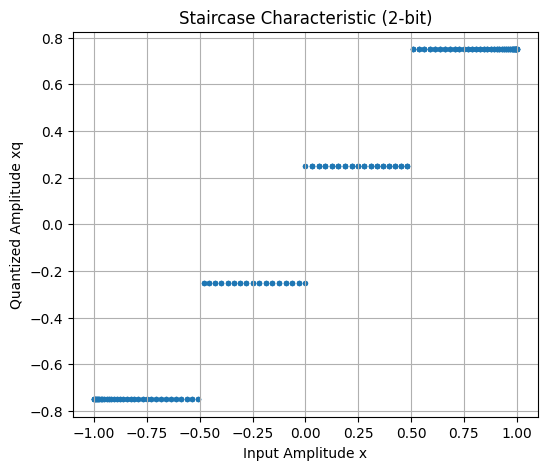

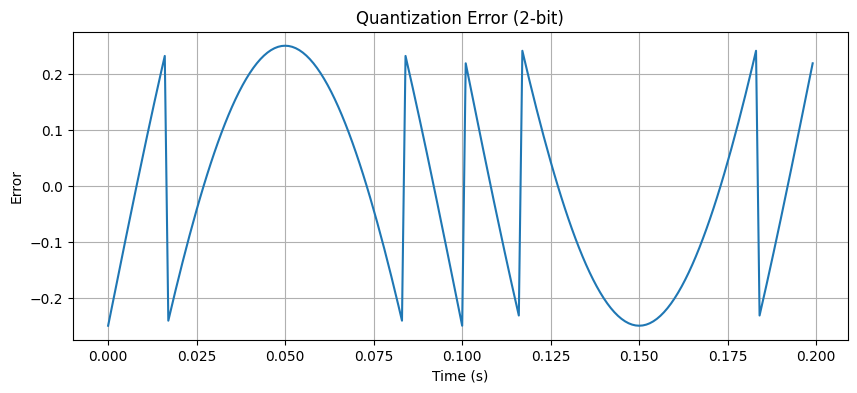

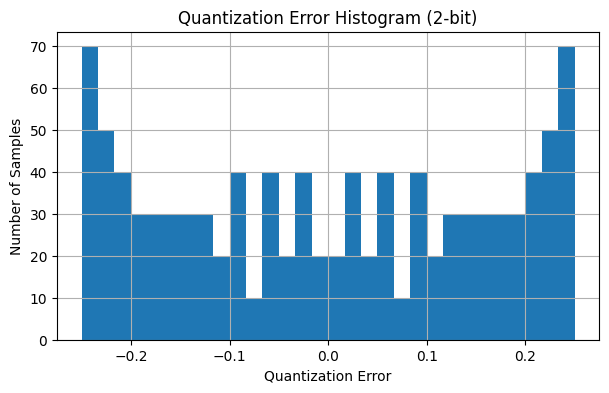


3-BIT QUANTIZATION
Number of levels: 8
Step size: 0.25
Index validation: True
PCM word length validation: True
First 10 quantization indices:
[4 4 4 4 4 4 4 4 4 5]
First 10 PCM words:
['100', '100', '100', '100', '100', '100', '100', '100', '100', '101']
MSE: 0.006201642889140326
Measured SQNR: 19.064632498099176 dB
Theoretical SQNR: 19.82 dB


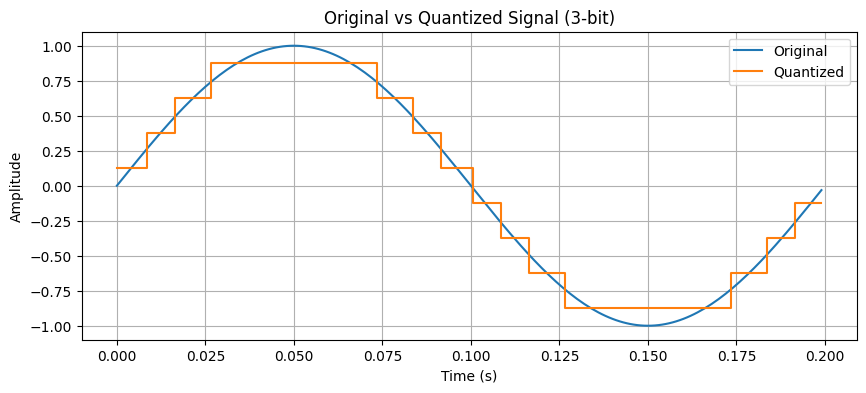

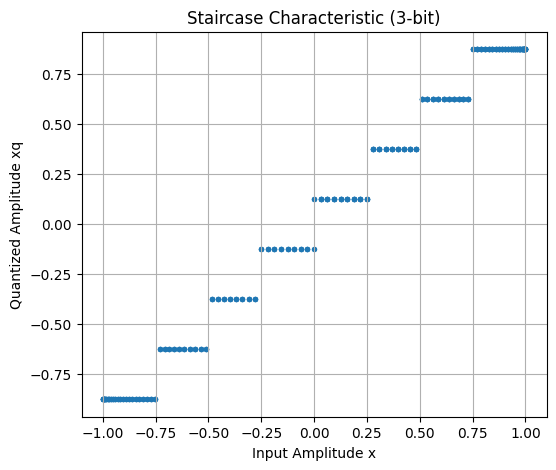

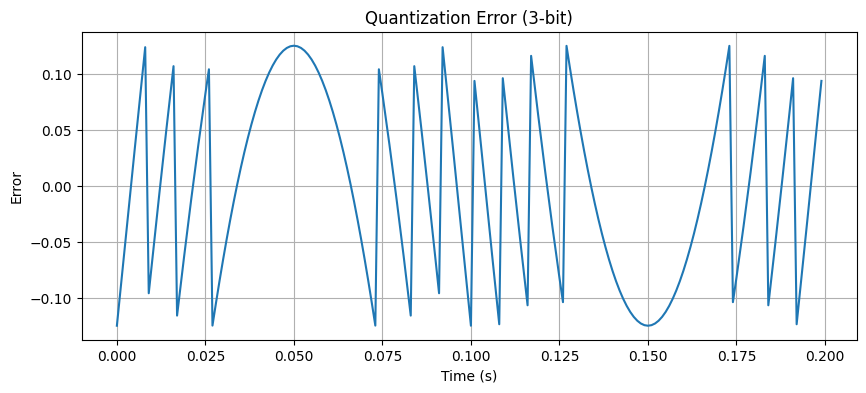

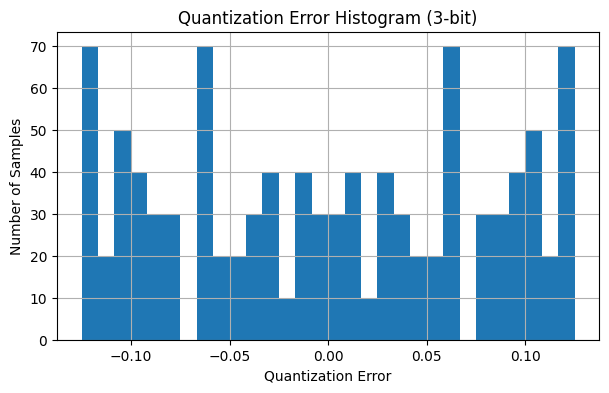


4-BIT QUANTIZATION
Number of levels: 16
Step size: 0.125
Index validation: True
PCM word length validation: True
First 10 quantization indices:
[ 8  8  8  8  9  9  9  9  9 10]
First 10 PCM words:
['1000', '1000', '1000', '1000', '1001', '1001', '1001', '1001', '1001', '1010']
MSE: 0.0015008209642231368
Measured SQNR: 25.22641116814598 dB
Theoretical SQNR: 25.84 dB


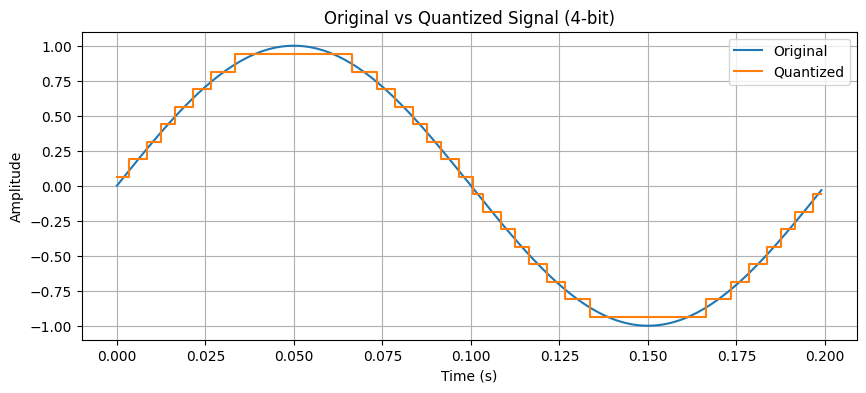

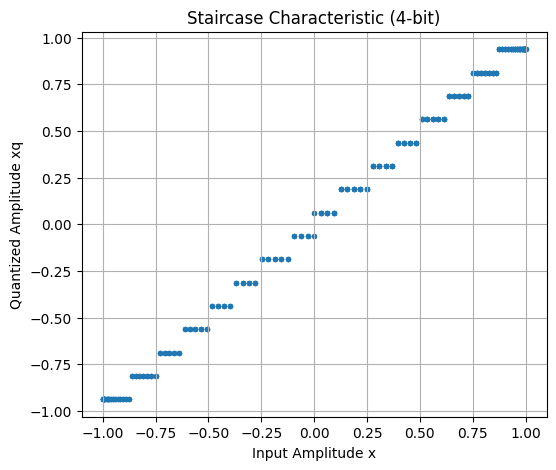

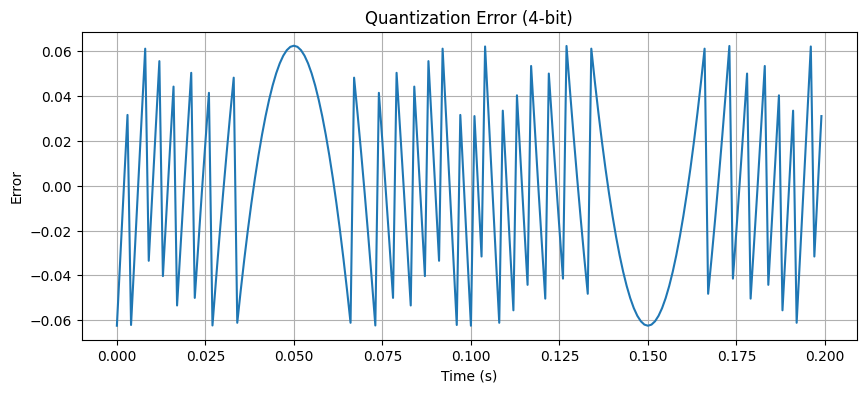

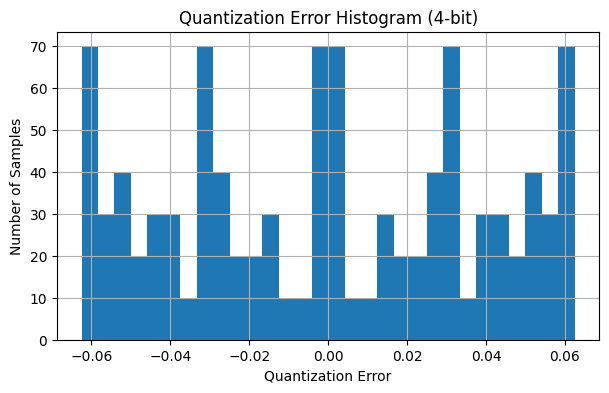


6-BIT QUANTIZATION
Number of levels: 64
Step size: 0.03125
Index validation: True
PCM word length validation: True
First 10 quantization indices:
[32 33 34 35 36 37 37 38 39 40]
First 10 PCM words:
['100000', '100001', '100010', '100011', '100100', '100101', '100101', '100110', '100111', '101000']
MSE: 0.00011619888571320197
Measured SQNR: 36.33768040919641 dB
Theoretical SQNR: 37.879999999999995 dB


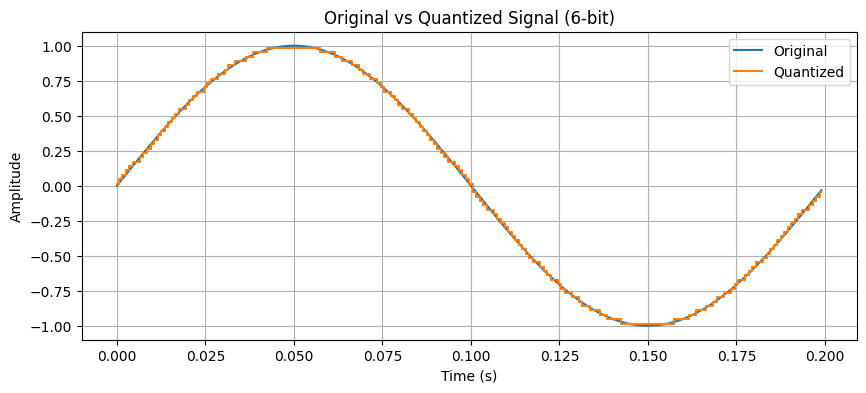

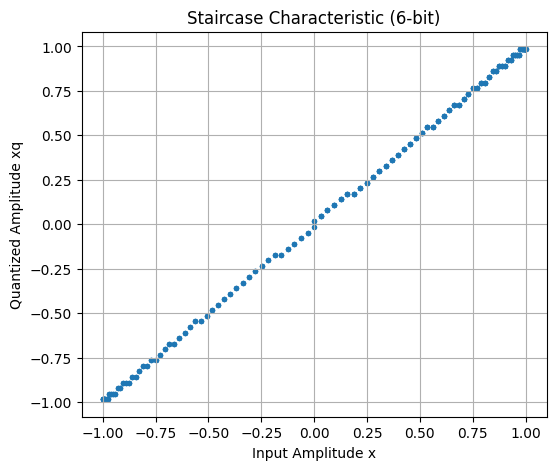

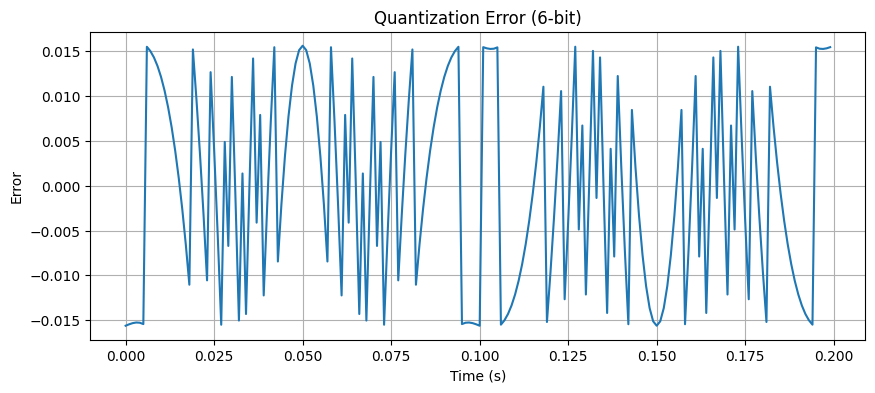

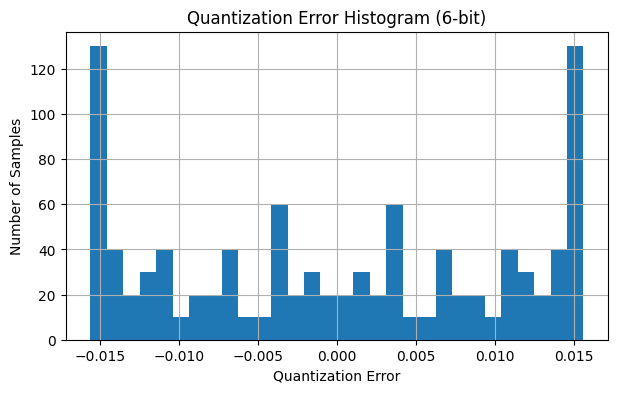


8-BIT QUANTIZATION
Number of levels: 256
Step size: 0.0078125
Index validation: True
PCM word length validation: True
First 10 quantization indices:
[128 132 136 140 144 148 151 155 159 163]
First 10 PCM words:
['10000000', '10000100', '10001000', '10001100', '10010000', '10010100', '10010111', '10011011', '10011111', '10100011']
MSE: 6.7092402906320716e-06
Measured SQNR: 48.72296657977101 dB
Theoretical SQNR: 49.919999999999995 dB


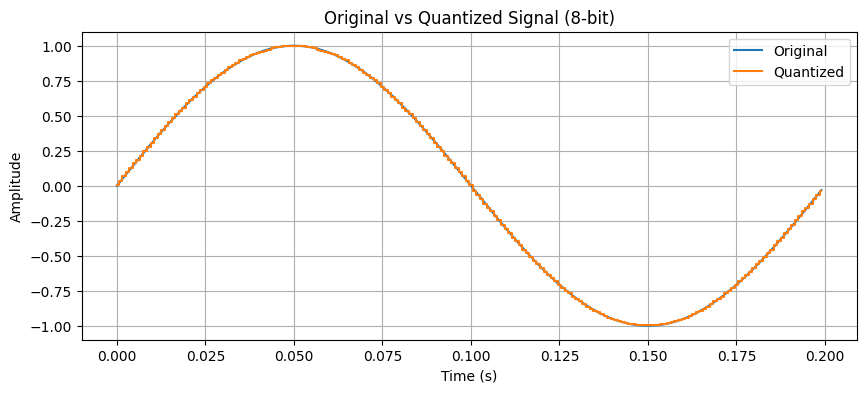

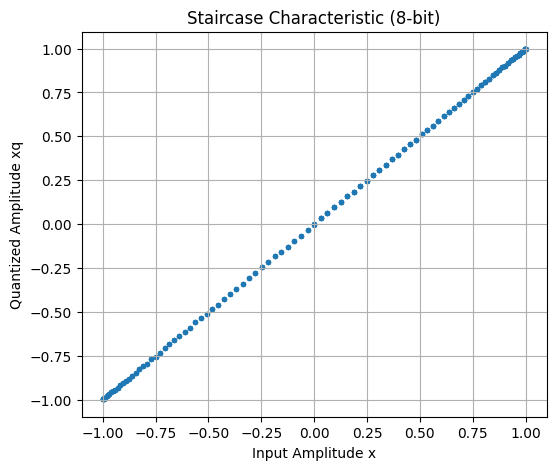

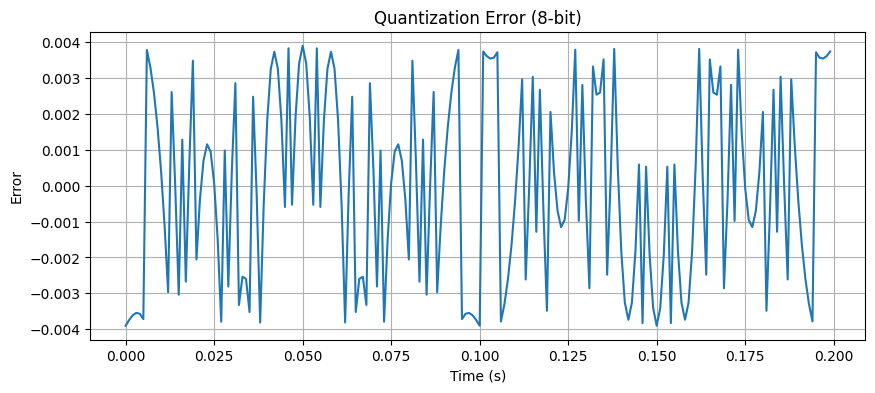

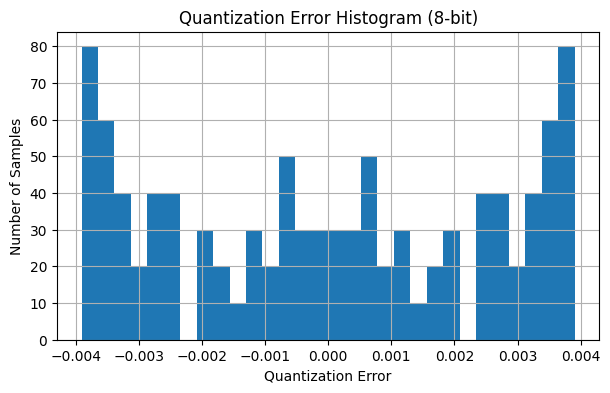




FINAL RESULTS
Bits    Levels    MSE            Measured SQNR       Theoretical SQNR
---------------------------------------------------------------------------
2       4         0.02620556     12.81               13.80 dB
3       8         0.00620164     19.06               19.82 dB
4       16        0.00150082     25.23               25.84 dB
6       64        0.00011620     36.34               37.88 dB
8       256       0.00000671     48.72               49.92 dB


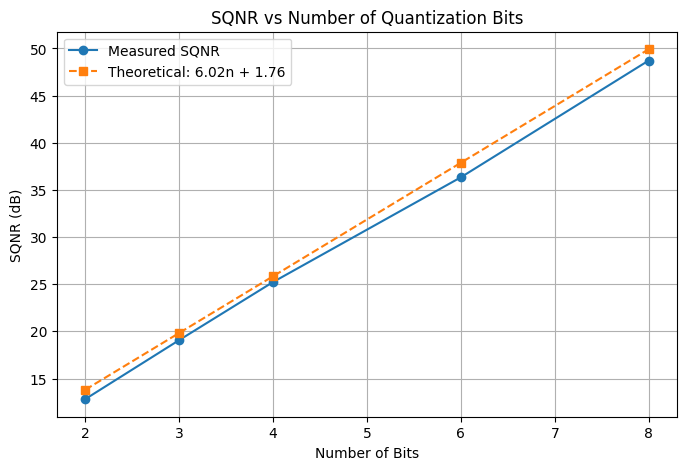


OBSERVATION:
As the number of quantization bits increases,
the number of quantization levels increases.
Therefore, quantization error decreases and SQNR increases.
The measured SQNR should approximately follow
the theoretical relation: SQNR = 6.02n + 1.76 dB.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# EXPERIMENT 4: UNIFORM QUANTIZATION AND PCM
# ============================================================

# ------------------------------------------------------------
# 1. Generate and normalize a sine wave
# ------------------------------------------------------------

f = 5                  # Signal frequency (Hz)
fs = 1000              # Sampling frequency (Hz)
T = 1                  # Duration (seconds)

t = np.arange(0, T, 1/fs)

# Original sine wave
x = np.sin(2 * np.pi * f * t)

# Normalize to [-1, 1]
x = x / np.max(np.abs(x))


# ------------------------------------------------------------
# 2. Bit resolutions to test
# ------------------------------------------------------------

bits_list = [2, 3, 4, 6, 8]

# Store results
results = []


# ------------------------------------------------------------
# 3. Uniform Quantization and PCM Encoding
# ------------------------------------------------------------

for n in bits_list:

    # Number of quantization levels
    L = 2 ** n

    # Quantization step size
    delta = 2 / L

    # --------------------------------------------------------
    # Quantization index
    # --------------------------------------------------------

    index = np.floor((x + 1) / delta).astype(int)

    # Mandatory validation:
    # index must be between 0 and L-1
    index = np.clip(index, 0, L - 1)

    # --------------------------------------------------------
    # Quantized signal
    # --------------------------------------------------------

    x_quant = -1 + (index + 0.5) * delta

    # --------------------------------------------------------
    # PCM binary words
    # --------------------------------------------------------

    pcm_words = [format(i, f'0{n}b') for i in index]

    # --------------------------------------------------------
    # Quantization error
    # --------------------------------------------------------

    error = x - x_quant

    # Mean Square Error
    mse = np.mean(error ** 2)

    # Signal power
    signal_power = np.mean(x ** 2)

    # Error power
    error_power = np.mean(error ** 2)

    # SQNR
    sqnr = 10 * np.log10(signal_power / error_power)

    # Theoretical SQNR
    theoretical_sqnr = 6.02 * n + 1.76

    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------

    index_valid = np.all((index >= 0) & (index <= L - 1))
    pcm_length_valid = all(len(word) == n for word in pcm_words)

    print("\n" + "=" * 60)
    print(f"{n}-BIT QUANTIZATION")
    print("=" * 60)

    print("Number of levels:", L)
    print("Step size:", delta)

    print("Index validation:", index_valid)
    print("PCM word length validation:", pcm_length_valid)

    print("First 10 quantization indices:")
    print(index[:10])

    print("First 10 PCM words:")
    print(pcm_words[:10])

    print("MSE:", mse)
    print("Measured SQNR:", sqnr, "dB")
    print("Theoretical SQNR:", theoretical_sqnr, "dB")

    # Store results
    results.append([
        n,
        L,
        mse,
        sqnr,
        theoretical_sqnr
    ])

    # --------------------------------------------------------
    # 4. Plot original and quantized waveform
    # --------------------------------------------------------

    plt.figure(figsize=(10, 4))

    # Plot only first 200 samples for clear visualization
    plt.plot(t[:200], x[:200], label="Original")
    plt.step(t[:200], x_quant[:200], where='mid',
             label="Quantized")

    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.title(f"Original vs Quantized Signal ({n}-bit)")
    plt.grid(True)
    plt.legend()
    plt.show()

    # --------------------------------------------------------
    # 5. Staircase characteristic
    # --------------------------------------------------------

    plt.figure(figsize=(6, 5))

    plt.scatter(x[:500], x_quant[:500], s=8)

    plt.xlabel("Input Amplitude x")
    plt.ylabel("Quantized Amplitude xq")
    plt.title(f"Staircase Characteristic ({n}-bit)")
    plt.grid(True)
    plt.show()

    # --------------------------------------------------------
    # 6. Quantization error waveform
    # --------------------------------------------------------

    plt.figure(figsize=(10, 4))

    plt.plot(t[:200], error[:200])

    plt.xlabel("Time (s)")
    plt.ylabel("Error")
    plt.title(f"Quantization Error ({n}-bit)")
    plt.grid(True)
    plt.show()

    # --------------------------------------------------------
    # 7. Error histogram
    # --------------------------------------------------------

    plt.figure(figsize=(7, 4))

    plt.hist(error, bins=30)

    plt.xlabel("Quantization Error")
    plt.ylabel("Number of Samples")
    plt.title(f"Quantization Error Histogram ({n}-bit)")
    plt.grid(True)
    plt.show()


# ------------------------------------------------------------
# 8. Display final results table
# ------------------------------------------------------------

print("\n\n")
print("=" * 75)
print("FINAL RESULTS")
print("=" * 75)

print(f"{'Bits':<8}{'Levels':<10}{'MSE':<15}"
      f"{'Measured SQNR':<20}{'Theoretical SQNR'}")

print("-" * 75)

for row in results:
    n, L, mse, sqnr, theoretical = row

    print(f"{n:<8}{L:<10}{mse:<15.8f}"
          f"{sqnr:<20.2f}{theoretical:.2f} dB")


# ------------------------------------------------------------
# 9. SQNR vs Number of Bits
# ------------------------------------------------------------

bits = [row[0] for row in results]
measured_sqnr = [row[3] for row in results]
theoretical_sqnr = [row[4] for row in results]

plt.figure(figsize=(8, 5))

plt.plot(bits, measured_sqnr, 'o-', label="Measured SQNR")
plt.plot(bits, theoretical_sqnr, 's--',
         label="Theoretical: 6.02n + 1.76")

plt.xlabel("Number of Bits")
plt.ylabel("SQNR (dB)")
plt.title("SQNR vs Number of Quantization Bits")
plt.grid(True)
plt.legend()
plt.show()


# ------------------------------------------------------------
# 10. Final observation
# ------------------------------------------------------------

print("\nOBSERVATION:")
print("As the number of quantization bits increases,")
print("the number of quantization levels increases.")
print("Therefore, quantization error decreases and SQNR increases.")
print("The measured SQNR should approximately follow")
print("the theoretical relation: SQNR = 6.02n + 1.76 dB.")